In [2]:
# --- Dependencies ---
# pip install torch torchvision torchaudio pandas numpy matplotlib scikit-learn tqdm pillow opencv-python

In [3]:
# --- Setup & Imports ---
import os, json, random, math, itertools, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
from collections import Counter, defaultdict
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image, UnidentifiedImageError 

# Data Cleaning

In [4]:
# --- Paths ---
# Point to the folder that contains your images and the _annotations.coco.json
INPUT_JSON = Path("../data/labeled_images/_annotations.coco.json")
OUTPUT_JSON  = INPUT_JSON.with_name(INPUT_JSON.stem + "_cleaned.json")

def load(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def save(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def ensure_cat_name(coco, name, supercat="person-state"):
    """Ensure a category by name exists (lowercase match); return its id."""
    for c in coco.get("categories", []):
        if c["name"].lower() == name.lower():
            # also normalize the canonical name to lowercase for 'alert'
            if name == "alert":
                c["name"] = "alert"
            return c["id"]
    new_id = (max([c["id"] for c in coco.get("categories", [])] + [0]) + 1)
    coco.setdefault("categories", []).append({"id": new_id, "name": name, "supercategory": supercat})
    return new_id

def clean_annotations():
    coco = load(INPUT_JSON)
    coco.setdefault("images", [])
    coco.setdefault("annotations", [])
    coco.setdefault("categories", [])

    # Identify face category ids (case-insensitive)
    face_ids = {c["id"] for c in coco["categories"] if c.get("name","").lower() == "face"}

    # Ensure alert/drowsy categories exist
    alert_id  = ensure_cat_name(coco, "alert")
    drowsy_id = ensure_cat_name(coco, "drowsy")

    # Build image_id -> primary label; also track images to drop
    primary = {}
    drop_image_ids = set()

    for img in coco["images"]:
        tags = [t.lower() for t in img.get("extra", {}).get("user_tags", []) if isinstance(t, str)]
        tagset = set(tags)

        # If both, keep only 'alert'
        if "alert" in tagset and "drowsy" in tagset:
            tagset = {"alert"}

        # Drop images with only 'uncertain'
        if tagset == {"uncertain"}:
            drop_image_ids.add(img["id"])
            continue

        # Determine primary label, and write back normalized tags
        if "alert" in tagset:
            primary_label = "alert"
            img.setdefault("extra", {}).setdefault("user_tags", [])
            img["extra"]["user_tags"] = ["alert"]
        elif "drowsy" in tagset:
            primary_label = "drowsy"
            img.setdefault("extra", {}).setdefault("user_tags", [])
            img["extra"]["user_tags"] = ["drowsy"]
        else:
            primary_label = None
            # keep any non-uncertain leftovers (optional)
            img.setdefault("extra", {}).setdefault("user_tags", [])
            img["extra"]["user_tags"] = sorted(t for t in tagset if t != "uncertain")

        primary[img["id"]] = primary_label

    # Remove dropped images and their annotations
    if drop_image_ids:
        coco["images"] = [im for im in coco["images"] if im["id"] not in drop_image_ids]
        coco["annotations"] = [a for a in coco["annotations"] if a["image_id"] not in drop_image_ids]

    # Now, for each FACE annotation, switch ONLY the category_id (keep bbox etc identical)
    changed = 0
    for ann in coco["annotations"]:
        if ann.get("category_id") in face_ids:
            label = primary.get(ann["image_id"])
            if label == "alert":
                ann["category_id"] = alert_id
                changed += 1
            elif label == "drowsy":
                ann["category_id"] = drowsy_id
                changed += 1
            # If neither tag present, leave as 'face' (no other field changes)

    # Save
    src = Path(INPUT_JSON)
    out = Path(OUTPUT_JSON) if OUTPUT_JSON else src.with_name(src.stem + "_face_to_state.json")
    save(coco, out)

    print(f"Converted {changed} face annotations to 'alert'/'drowsy' while keeping bboxes identical.")
    print(f"Dropped {len(drop_image_ids)} images (only 'uncertain').")
    print(f"Output: {out}")

clean_annotations()

Converted 3159 face annotations to 'alert'/'drowsy' while keeping bboxes identical.
Dropped 0 images (only 'uncertain').
Output: ..\data\labeled_images\_annotations.coco_cleaned.json


In [5]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.use_deterministic_algorithms(True)
set_seed(42)

# Choose GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# ResNet-18 Classifier Model

Total crops: 3159 | Label dist (0=Drowsy,1=Alert) -> {0: 1560, 1: 1599}
Train: 2127 | Val: 558 | Test: 474

Grid size: 8 trials


=== Trial: head0p001_l40p001_l30p001 ===


Train | epoch 01: 100%|██████████| 67/67 [02:00<00:00,  1.80s/it, acc=0.8698, loss=0.3227]
                                                                 

[head=1.0e-03, l4=1.0e-03, l3=1.0e-03] Epoch 01/12 | Train 0.3227/0.8698 | Val 0.4474/0.8262


Train | epoch 02: 100%|██████████| 67/67 [01:40<00:00,  1.50s/it, acc=0.9408, loss=0.1646]
                                                                 

[head=1.0e-03, l4=1.0e-03, l3=1.0e-03] Epoch 02/12 | Train 0.1646/0.9408 | Val 0.3729/0.8907


...

Train | epoch 11: 100%|██████████| 67/67 [02:00<00:00,  1.80s/it, acc=0.9882, loss=0.0340]
                                                                 

[head=1.0e-04, l4=1.0e-04, l3=1.0e-04] Epoch 11/12 | Train 0.0340/0.9882 | Val 0.1950/0.9427


Train | epoch 12: 100%|██████████| 67/67 [01:59<00:00,  1.78s/it, acc=0.9901, loss=0.0252]
                                                                 

[head=1.0e-04, l4=1.0e-04, l3=1.0e-04] Epoch 12/12 | Train 0.0252/0.9901 | Val 0.2952/0.9104



=== Best trial summary ===
{'val_acc': 0.9605734767025089, 'trial_name': 'head0p0001_l40p0001_l30p001', 'state_dict': OrderedDict({'conv1.weight': tensor([[[[-1.0419e-02, -6.1356e-03, -1.8098e-03,  ...,  5.6615e-02,
            1.7083e-02, -1.2694e-02],
          [ 1.1083e-02,  9.5276e-03, -1.0993e-01,  ..., -2.7124e-01,
           -1.2907e-01,  3.7424e-03],
          [-6.9434e-03,  5.9089e-02,  2.9548e-01,  ...,  5.1972e-01,
            2.5632e-01,  6.3573e-02],
          ...,
          [-2.7535e-02,  1.6045e-02,  7.2595e-02,  ..., -3.3285e-01,
           -4.2058e-01, -2.5781e-01],
          [ 3.0613e-02,  4.0960e-02,  6.2850e-02,  ...,  4.1384e-01,
            3.9359e-01,  1.6606e-01],
          [-1.3736e-02, -3.6746e-03, -2.4084e-02,  ..., -1.5070e-01,
           -8.2230e-02, -5.7828e-03]],

         [[-1.1397e-02, -2.6619e-02, -3.4641e-02,  ...,  3.2521e-02,
            6.6221e-04, -2.5743e-02],
          [ 4.5687e-02,  3.3603e-02, -1.0453e-01,  ..., -3.1253e-01,
           -1.605

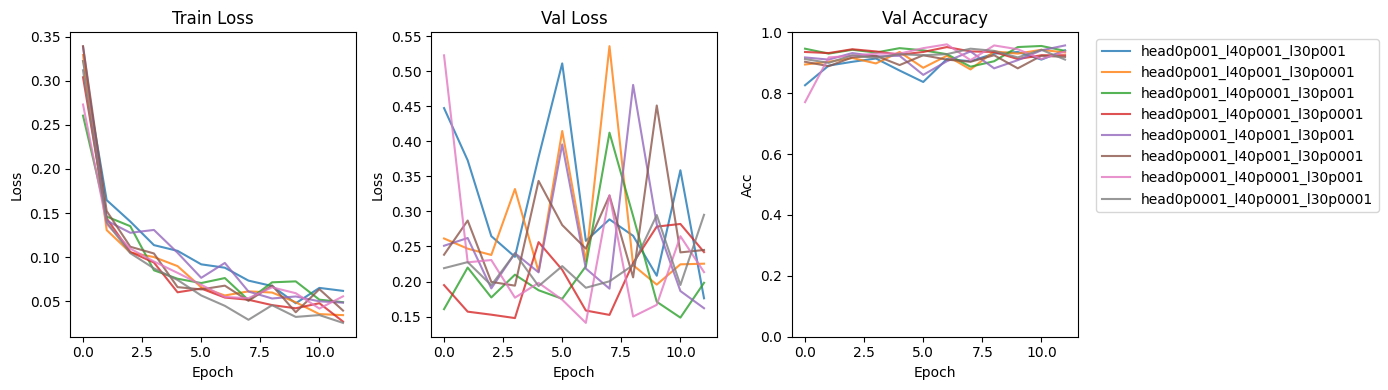

TypeError: Object of type Tensor is not JSON serializable

In [7]:
# ---------- Tiny JSON helpers ----------
def read_json(path):
    p = Path(path)
    with p.open("r", encoding="utf-8") as f:
        return json.load(f)

def write_json(obj, path):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    with p.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

# ---------- Config ----------
CFG = dict(
    img_size=224,            # ResNet-18 input size
    batch_size=32,
    num_workers=0,
    pin_memory=False,

    # Train/val/test split (stratified)
    test_size=0.15,          # 15% test
    val_size=0.1765,         # 15% of total ≈ 0.1765 of remaining 85% (0.85 * 0.1765 ≈ 0.15) => 70/15/15 split
    random_state=42,

    # Cropping robustness
    context_scale=1.20,      # expand bbox by +20% around center to keep helpful context (eyelids/brow/cheeks)
    min_crop_size=8,         # avoid tiny/degenerate crops

    # Training budget
    epochs=12,               # ≤ 15 as requested
    weight_decay=0.0,        # simple base; you can add [0, 1e-4] to the grid if you want

    # Learning-rate sweep (small & sensible)
    lr_head_candidates=[1e-3, 1e-4],
    lr_l4_candidates=[1e-3, 1e-4],
    lr_l3_candidates=[1e-3, 1e-4],
)


CNN = Path("cnn"); CNN.mkdir(exist_ok=True)
# ---------- Load cleaned COCO & index images ----------
CLEAN_JSON = OUTPUT_JSON
coco = read_json(CLEAN_JSON)
data_root = INPUT_JSON.parent  # folder that contains images referenced by file_name


def build_img_index(coco, data_root: Path):
    idx = {}
    for img in coco.get("images", []):
        rel = Path(img.get("file_name", ""))
        p = (data_root / rel).resolve()
        if p.exists():
            idx[img["id"]] = (str(p), img.get("width"), img.get("height"))
    return idx

img_index = build_img_index(coco, data_root)

name_to_id = {c["name"].lower(): c["id"] for c in coco.get("categories", [])}
ALERT_ID  = name_to_id.get("alert", 7)
DROWSY_ID = name_to_id.get("drowsy", 8)

# Build (img_path, bbox, y) samples from annotations
samples = []
for ann in coco.get("annotations", []):
    cid = ann.get("category_id")
    if cid not in (ALERT_ID, DROWSY_ID): 
        continue
    img_id = ann.get("image_id")
    if img_id not in img_index:
        continue
    img_path, W, H = img_index[img_id]
    bbox = ann.get("bbox")
    if not bbox or len(bbox) != 4:
        continue
    y = 1 if cid == ALERT_ID else 0
    samples.append((img_path, tuple(bbox), y))

if not samples:
    raise RuntimeError("No crops found for category_id 7/8 in annotations.")
print(f"Total crops: {len(samples)} | Label dist (0=Drowsy,1=Alert) -> {dict(Counter([s[2] for s in samples]))}")

# ----------------------------
# Dataset: robust bbox crop → tensor
# ----------------------------
class CropDataset(Dataset):
    """
    For each annotation: open image → expand + clip bbox → crop → augment/normalize → (tensor, label)
    """
    def __init__(self, samples, transform, context_scale=1.20, min_size=8):
        self.samples = samples
        self.transform = transform
        self.context_scale = context_scale
        self.min_size = min_size

    def __len__(self): return len(self.samples)

    def _expand_and_clip(self, x, y, w, h, W, H):
        # Expand around center to keep helpful context (eyelids/brows/cheeks/forehead)
        cx = x + w/2.0; cy = y + h/2.0
        w2 = w * self.context_scale; h2 = h * self.context_scale
        x1 = int(round(cx - w2/2.0)); y1 = int(round(cy - h2/2.0))
        x2 = int(round(cx + w2/2.0)); y2 = int(round(cy + h2/2.0))
        # Clip to bounds and enforce minimum size
        x1 = max(0, min(x1, W-1)); y1 = max(0, min(y1, H-1))
        x2 = max(1, min(x2, W));   y2 = max(1, min(y2, H))
        if x2 - x1 < self.min_size: x2 = min(W, x1 + self.min_size)
        if y2 - y1 < self.min_size: y2 = min(H, y1 + self.min_size)
        return x1, y1, x2, y2

    def __getitem__(self, idx):
        img_path, bbox, y = self.samples[idx]
        try:
            img = Image.open(img_path).convert("RGB")
        except (UnidentifiedImageError, OSError) as e:
            raise RuntimeError(f"Failed to open image: {img_path}") from e
        W, H = img.size
        x, y0, w, h = bbox
        x1, y1, x2, y2 = self._expand_and_clip(x, y0, w, h, W, H)
        crop = img.crop((x1, y1, x2, y2))
        crop = self.transform(crop)
        return crop, y

# ----------------------------
# Light augmentations (train) + eval transforms (val/test)
# ----------------------------
train_tfm = transforms.Compose([
    # Light random crop: sample a slightly smaller area, then resize back
    transforms.RandomResizedCrop(
        size=CFG["img_size"], scale=(0.9, 1.0), ratio=(0.9, 1.1)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
eval_tfm = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ----------------------------
# Train/Val/Test split (stratified)
# ----------------------------
all_idx = np.arange(len(samples))
y_all = np.array([samples[i][2] for i in all_idx])

# First: test split
idx_trv, idx_te = train_test_split(
    all_idx, test_size=CFG["test_size"], random_state=CFG["random_state"], stratify=y_all
)
y_trv = y_all[idx_trv]

# Then: val split from the remaining
val_ratio_of_trv = CFG["val_size"] / (1.0 - CFG["test_size"])
idx_tr, idx_va = train_test_split(
    idx_trv, test_size=val_ratio_of_trv, random_state=CFG["random_state"], stratify=y_trv
)

train_samples = [samples[i] for i in idx_tr]
val_samples   = [samples[i] for i in idx_va]
test_samples  = [samples[i] for i in idx_te]

print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")

train_loader = DataLoader(
    CropDataset(train_samples, transform=train_tfm,
                context_scale=CFG["context_scale"], min_size=CFG["min_crop_size"]),
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=0,   
    pin_memory=False       
)

val_loader = DataLoader(
    CropDataset(val_samples, transform=eval_tfm,
                context_scale=CFG["context_scale"], min_size=CFG["min_crop_size"]),
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    CropDataset(test_samples, transform=eval_tfm,
                context_scale=CFG["context_scale"], min_size=CFG["min_crop_size"]),
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# ----------------------------
# Model builder: load ResNet18 (pretrained), unfreeze last 2 blocks + head
# ----------------------------
def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_feats = m.fc.in_features
    m.fc = nn.Linear(in_feats, 2)          # simple linear head

    # freeze everything first
    for p in m.parameters():
        p.requires_grad = False
    # unfreeze head + last two blocks
    for p in m.fc.parameters():        p.requires_grad = True
    for p in m.layer4.parameters():    p.requires_grad = True
    for p in m.layer3.parameters():    p.requires_grad = True
    return m

# ----------------------------
# One training run for given LR combo; returns best epoch (by Val Acc)
# ----------------------------
def train_eval_once(lr_head, lr_l4, lr_l3, weight_decay, epochs):
    model = build_model().to(device)

    # Discriminative LRs for groups
    params = [
        {"params": model.fc.parameters(),     "lr": lr_head, "weight_decay": weight_decay},
        {"params": model.layer4.parameters(), "lr": lr_l4,   "weight_decay": weight_decay},
        {"params": model.layer3.parameters(), "lr": lr_l3,   "weight_decay": weight_decay},
    ]
    optimizer = optim.AdamW(params)
    criterion = nn.CrossEntropyLoss()

    history = {"tr_loss": [], "va_loss": [], "va_acc": []}
    best = {"val_acc": -1.0, "epoch": -1, "state_dict": None}

    def evaluate(loader, epoch_idx):
        model.eval()
        total, correct, loss_sum = 0, 0, 0.0
        # nice live bar for validation too
        for x, y in tqdm(
            loader, desc=f"Val   | epoch {epoch_idx:02d}", leave=False, dynamic_ncols=True
        ):
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                logits = model(x)
                loss = criterion(logits, y)
            loss_sum += loss.item() * x.size(0)
            pred = logits.argmax(1)
            total += y.size(0); correct += (pred == y).sum().item()
        return loss_sum/total, correct/total

    def train_one_epoch(epoch_idx):
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        # live train bar with throughput
        pbar = tqdm(
            train_loader, desc=f"Train | epoch {epoch_idx:02d}", leave=True, dynamic_ncols=True
        )
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            # stats
            loss_sum += loss.item() * x.size(0)
            pred = logits.argmax(1)
            total += y.size(0); correct += (pred == y).sum().item()

            # update bar postfix with running metrics
            curr_loss = loss_sum / max(total, 1)
            curr_acc  = correct / max(total, 1)
            pbar.set_postfix(loss=f"{curr_loss:.4f}", acc=f"{curr_acc:.4f}")
        return loss_sum/total, correct/total

    # Train loop (shows per-epoch bars + summary)
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(ep)
        va_loss, va_acc = evaluate(val_loader, ep)

        history["tr_loss"].append(tr_loss)
        history["va_loss"].append(va_loss)
        history["va_acc"].append(va_acc)

        # epoch summary (flush so you see it immediately)
        print(
            f"[head={lr_head:.1e}, l4={lr_l4:.1e}, l3={lr_l3:.1e}] "
            f"Epoch {ep:02d}/{epochs:02d} | Train {tr_loss:.4f}/{tr_acc:.4f} | "
            f"Val {va_loss:.4f}/{va_acc:.4f}",
            flush=True
        )

        # keep best epoch by Val Acc
        if va_acc > best["val_acc"] + 1e-12:
            best["val_acc"] = va_acc
            best["epoch"] = ep
            best["state_dict"] = model.state_dict()

    return best, history
# ----------------------------
# Grid search over LR combos
# ----------------------------
search = list(itertools.product(
    CFG["lr_head_candidates"], CFG["lr_l4_candidates"], CFG["lr_l3_candidates"]))
print(f"\nGrid size: {len(search)} trials\n")

trial_histories = {}   # for plotting all modes
best_overall = {"val_acc": -1.0, "trial_name": None, "state_dict": None, "epoch": -1, "hparams": None}

for (lr_head, lr_l4, lr_l3) in search:
    name = f"head{lr_head}_l4{lr_l4}_l3{lr_l3}".replace(".", "p")
    print(f"\n=== Trial: {name} ===")
    best_ep, history = train_eval_once(
        lr_head=lr_head, lr_l4=lr_l4, lr_l3=lr_l3,
        weight_decay=CFG["weight_decay"], epochs=CFG["epochs"]
    )
    trial_histories[name] = history

    if best_ep["val_acc"] > best_overall["val_acc"] + 1e-12:
        best_overall.update(dict(
            val_acc=best_ep["val_acc"],
            trial_name=name,
            state_dict=best_ep["state_dict"],
            epoch=best_ep["epoch"],
            hparams=dict(lr_head=lr_head, lr_l4=lr_l4, lr_l3=lr_l3, weight_decay=CFG["weight_decay"])
        ))

print("\n=== Best trial summary ===")
print(best_overall)

# ----------------------------
# Plot losses/accuracy for all modes
# ----------------------------
plt.figure(figsize=(14,4))
# Train Loss
plt.subplot(1,3,1)
for name, h in trial_histories.items():
    plt.plot(h["tr_loss"], label=name, alpha=0.8)
plt.title("Train Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
# Val Loss
plt.subplot(1,3,2)
for name, h in trial_histories.items():
    plt.plot(h["va_loss"], label=name, alpha=0.8)
plt.title("Val Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss")
# Val Acc
plt.subplot(1,3,3)
for name, h in trial_histories.items():
    plt.plot(h["va_acc"], label=name, alpha=0.8)
plt.title("Val Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ----------------------------
# Evaluate best model on TEST set, save weights + reports
# ----------------------------
best_weights_path = CNN / f"best_resnet18_last2_{best_overall['trial_name']}_ep{best_overall['epoch']}.pth"
torch.save(best_overall["state_dict"], best_weights_path)
write_json({"0": "Drowsy", "1": "Alert"}, CNN / "class_map.json")
write_json({"best": best_overall}, CNN / "best_trial.json")

# Rebuild and load best model weights
best_model = build_model().to(device)
best_model.load_state_dict(best_overall["state_dict"])
best_model.eval()

# Collect predictions on TEST set
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = best_model(x)
        pred = logits.argmax(1).cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# Metrics
test_acc = accuracy_score(y_true, y_pred)
report = classification_report(
    y_true, y_pred,
    target_names=["Drowsy (0)", "Alert (1)"],
    digits=4
)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Print
print(f"\nFinal TEST accuracy of best model: {test_acc:.4f}")
print("\nClassification report (TEST):")
print(report)
print("Confusion matrix (rows=true, cols=pred):\n", cm)

# Save metrics & report artifacts
write_json(
    {"test_accuracy": float(test_acc),
     "confusion_matrix": cm.tolist(),
     "hparams": best_overall["hparams"],
     "best_trial": best_overall["trial_name"],
     "best_epoch": best_overall["epoch"]},
    CNN / "test_metrics.json"
)

# Save the text report too
with open(CNN / "test_classification_report.txt", "w") as f:
    f.write(f"TEST accuracy: {test_acc:.6f}\n\n")
    f.write(report)

# Plot & save confusion matrix
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (TEST)")
plt.xticks([0,1], ["Drowsy","Alert"])
plt.yticks([0,1], ["Drowsy","Alert"])
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(CNN / "test_confusion_matrix.png", dpi=160)
plt.show()

print(f"Saved best model → {best_weights_path}")
print(f"Class map       → {CNN / 'class_map.json'}")
print(f"Best trial meta → {CNN / 'best_trial.json'}")
print(f"Test metrics    → {CNN / 'test_metrics.json'}")
print(f"Test report     → {CNN / 'test_classification_report.txt'}")
print(f"CM image        → {CNN / 'test_confusion_matrix.png'}")